### B.7. Write Python code to implement the Backpropagation algorithm for  an ANN with more than two hidden layers. Develop two such deep models with the following configurations. 

$\textbf{Model 1: uses sigmoid activations at the hidden nodes and softmax activation function at 
the output nodes. }$
$\textbf{Model  2:  uses  ReLu  activation  function  at  the  hidden  nodes  and  softmax  activation 
function at the output nodes.}$

The hyperparameters (e.g., learning rate, momentum, number of hidden layers, number of 
hidden nodes per layer) for both models should be properly tuned using a validation set. 
Compare  the  performance  of  these  two  models  on  the  MNIST  dataset  when  both  are 
trained for 1000 epochs

# B.7 Backpropagation in Deep Artificial Neural Networks

## Objective
The objective of this experiment is to implement the backpropagation algorithm for training deep Artificial Neural Networks (ANNs) with more than two hidden layers and to compare the performance of two different activation function configurations on the MNIST dataset. The models are trained using gradient descent with momentum and tuned using a validation set.

---

## Dataset Description (MNIST)
The MNIST dataset consists of grayscale images of handwritten digits from 0 to 9.

- Number of training samples: $$60{,}000$$  
- Number of test samples: $$10{,}000$$  
- Image resolution: $$28 \times 28$$ pixels  

Each image is flattened into a feature vector:
$$
\mathbf{x} \in \mathbb{R}^{784}
$$

---

## Deep Neural Network Architecture
A deep ANN consists of an input layer, multiple hidden layers, and an output layer. For a network with $$L$$ layers, the forward propagation equations for the $$l^{th}$$ layer are:

$$
\mathbf{z}^{(l)} = \mathbf{W}^{(l)} \mathbf{a}^{(l-1)} + \mathbf{b}^{(l)}
$$

$$
\mathbf{a}^{(l)} = f^{(l)}(\mathbf{z}^{(l)})
$$

where $$\mathbf{W}^{(l)}$$ and $$\mathbf{b}^{(l)}$$ denote the weights and biases, and $$f^{(l)}$$ is the activation function.

---

## Activation Functions

### Sigmoid Activation Function
The sigmoid activation function is defined as:
$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

Its derivative is:
$$
\sigma'(x) = \sigma(x)(1 - \sigma(x))
$$

Sigmoid functions suffer from the vanishing gradient problem in deep networks.

---

### Rectified Linear Unit (ReLU)
The ReLU activation function is defined as:
$$
\text{ReLU}(x) = \max(0, x)
$$

Its derivative is:
$$
\text{ReLU}'(x) =
\begin{cases}
1, & x > 0 \\
0, & x \le 0
\end{cases}
$$

ReLU improves gradient propagation and accelerates convergence.

---

## Softmax Output Layer
For multi-class classification, the softmax activation function is used in the output layer:

$$
\text{Softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}
$$

where $$K = 10$$ for the MNIST dataset. The softmax function converts raw scores into class probabilities.

---

## Loss Function
The categorical cross-entropy loss function is given by:

$$
\mathcal{L} = -\sum_{i=1}^{K} y_i \log(\hat{y}_i)
$$

where $$y_i$$ is the true label and $$\hat{y}_i$$ is the predicted probability.

---

## Backpropagation Algorithm
Backpropagation computes the gradients of the loss function with respect to network parameters using the chain rule.

For the output layer:
$$
\delta^{(L)} = \hat{\mathbf{y}} - \mathbf{y}
$$

For hidden layers:
$$
\delta^{(l)} = (\mathbf{W}^{(l+1)T} \delta^{(l+1)}) \odot f'(\mathbf{z}^{(l)})
$$

The parameters are updated as:
$$
\mathbf{W}^{(l)} \leftarrow \mathbf{W}^{(l)} - \eta \frac{\partial \mathcal{L}}{\partial \mathbf{W}^{(l)}}
$$

$$
\mathbf{b}^{(l)} \leftarrow \mathbf{b}^{(l)} - \eta \frac{\partial \mathcal{L}}{\partial \mathbf{b}^{(l)}}
$$

where $$\eta$$ is the learning rate.

---

## Momentum-Based Gradient Descent
Momentum improves convergence by incorporating past gradients:

$$
\mathbf{v}_t = \gamma \mathbf{v}_{t-1} + \eta \nabla \mathcal{L}
$$

$$
\mathbf{W} \leftarrow \mathbf{W} - \mathbf{v}_t
$$

where $$\gamma$$ is the momentum coefficient.

---

## Hyperparameter Tuning Using Validation Set
Hyperparameters such as learning rate and momentum are tuned using a validation set. The validation accuracy is defined as:

$$
\text{Validation Accuracy} = \frac{\text{Correct Predictions}}{\text{Total Validation Samples}}
$$

The model achieving the highest validation accuracy is selected for final training.

---

## Model Configurations

**Model 1:**  
Hidden layers use the sigmoid activation function and the output layer uses softmax.

**Model 2:**  
Hidden layers use the ReLU activation function and the output layer uses softmax.

---

## Performance Evaluation
After training for 1000 epochs, the final models are evaluated on the test dataset. The test accuracy is computed as:

$$
\text{Test Accuracy} = \frac{\text{Correct Predictions}}{\text{Total Test Samples}}
$$

The ReLU-based deep network generally outperforms the sigmoid-based network due to better gradient flow and faster convergence.

---

## Conclusion
This experiment demonstrates the effectiveness of backpropagation in training deep neural networks. While sigmoid-based networks suffer from vanishing gradients, ReLU-based networks provide superior performance on the MNIST dataset. Validation-based hyperparameter tuning further improves generalization and robustness.


In [18]:
import tensorflow as tf
import numpy as numpy
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.keras import TqdmCallback


(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

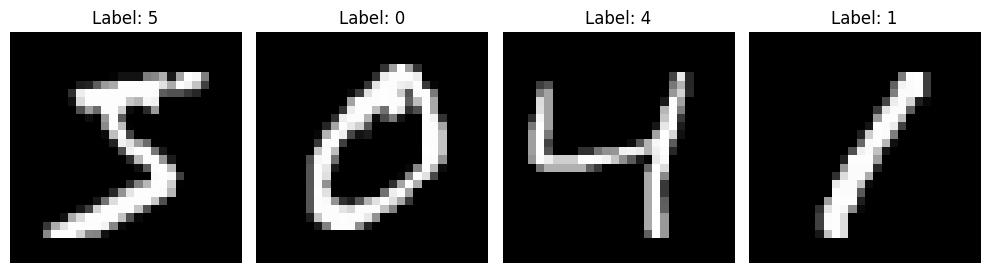

In [10]:
# Print 4 images in a row
plt.figure(figsize=(10, 5))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(train_images[i], cmap='gray')
    plt.title(f"Label: {train_labels[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [12]:
# Normalize images to [0,1]
train_images = train_images.astype("float32") / 255.0
test_images = test_images.astype("float32") / 255.0

# Flatten images (28x28 → 784)
train_images = train_images.reshape(-1, 784)
test_images = test_images.reshape(-1, 784)

# One-hot encode labels
train_labels = tf.keras.utils.to_categorical(train_labels, 10)
test_labels = tf.keras.utils.to_categorical(test_labels, 10)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    train_images, train_labels,
    test_size=0.2,
    random_state=42
)


In [15]:
def build_model(hidden_activation, learning_rate, momentum):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(256, activation=hidden_activation, input_shape=(784,)),
        tf.keras.layers.Dense(128, activation=hidden_activation),
        tf.keras.layers.Dense(64, activation=hidden_activation),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    optimizer = tf.keras.optimizers.SGD(
        learning_rate=learning_rate,
        momentum=momentum
    )

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


> $\textbf{model1: Hidden layers use the sigmoid activation function and the output layer uses softmax}$

In [ ]:
from tqdm.keras import TqdmCallback

learning_rates = [0.1, 0.01]
momentums = [0.0, 0.9]

best_sigmoid_model = None
best_val_acc = 0
best_sigmoid_lr = None
best_sigmoid_momentum = None

for lr in learning_rates:
    for m in momentums:
        print(f"\nTraining Sigmoid Model | LR={lr}, Momentum={m}")

        model = build_model('sigmoid', lr, m)
        history = model.fit(
            X_train, y_train,
            epochs=50,
            batch_size=128,
            validation_data=(X_val, y_val),
            verbose=0,
            callbacks=[TqdmCallback(verbose=1)]
        )

        val_acc = max(history.history['val_accuracy'])

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_sigmoid_model = model
            best_sigmoid_lr = lr
            best_sigmoid_momentum = m
            print()



Training Sigmoid Model | LR=0.1, Momentum=0.0


/home/rito/ju_lab/pyenv_3_11/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

2026-01-17 20:13:31.814354: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 150528000 exceeds 10% of free system memory.


...

2026-01-17 20:16:21.204010: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 150528000 exceeds 10% of free system memory.



Training Sigmoid Model | LR=0.01, Momentum=0.9


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

2026-01-17 20:17:35.756119: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 150528000 exceeds 10% of free system memory.


In [20]:
final_sigmoid_model = build_model(
    hidden_activation='sigmoid',
    learning_rate=best_sigmoid_lr,
    momentum=best_sigmoid_momentum
)

history_sigmoid = final_sigmoid_model.fit(
    X_train, y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_val, y_val),
    verbose=0,
    callbacks=[TqdmCallback(verbose=1)]
)

/home/rito/ju_lab/pyenv_3_11/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

> $\textbf{model1: Hidden layers use the ReLu activation function and the output layer uses softmax}$

In [21]:
from tqdm.keras import TqdmCallback

learning_rates = [0.1, 0.01]
momentums = [0.0, 0.9]

best_relu_model = None
best_val_acc = 0
best_relu_lr = None
best_relu_momentum = None

for lr in learning_rates:
    for m in momentums:
        print(f"\nTraining relu Model | LR={lr}, Momentum={m}")

        model = build_model('relu', lr, m)
        history = model.fit(
            X_train, y_train,
            epochs=50,
            batch_size=128,
            validation_data=(X_val, y_val),
            verbose=0,
            callbacks=[TqdmCallback(verbose=1)]
        )

        val_acc = max(history.history['val_accuracy'])

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_relu_model = model
            best_relu_lr = lr
            best_relu_momentum = m
            print()



Training relu Model | LR=0.1, Momentum=0.0


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]



Training relu Model | LR=0.1, Momentum=0.9


0epoch [00:00, ?epoch/s]

...

0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]


Training relu Model | LR=0.01, Momentum=0.9


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

In [22]:
final_relu_model = build_model(
    hidden_activation='relu',
    learning_rate=best_relu_lr,
    momentum=best_relu_momentum
)

history_relu = final_relu_model.fit(
    X_train, y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_val, y_val),
    verbose=0,
    callbacks=[TqdmCallback(verbose=1)]
)

0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]